In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [86]:
process_df = pd.read_excel("_h_batch_process_data.xlsx")
production_df = pd.read_excel("_h_batch_production_data.xlsx")

# Ensure same datatype for merge
process_df["Batch_ID"] = process_df["Batch_ID"].astype(str)
production_df["Batch_ID"] = production_df["Batch_ID"].astype(str)

# Merge
df = pd.merge(process_df, production_df, on="Batch_ID")

print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (211, 25)


,Batch_ID,Time_Minutes,Phase,Temperature_C,Pressure_Bar,Humidity_Percent,Motor_Speed_RPM,Compression_Force_kN,Flow_Rate_LPM,Power_Consumption_kW,...,Compression_Force,Machine_Speed,Lubricant_Conc,Moisture_Content,Tablet_Weight,Hardness,Friability,Disintegration_Time,Dissolution_Rate,Content_Uniformity
0,T001,0,Preparation,22.844876,1.023866,39.089956,0.0,0.0,0.0,2.022778,...,12.5,150,1.0,2.1,199.8,95,0.65,8.2,89.3,98.7
1,T001,1,Preparation,24.892949,1.170301,46.608042,0.0,0.0,0.0,1.164997,...,12.5,150,1.0,2.1,199.8,95,0.65,8.2,89.3,98.7
2,T001,2,Preparation,26.782330,0.868381,47.701284,0.0,0.0,0.0,2.613172,...,12.5,150,1.0,2.1,199.8,95,0.65,8.2,89.3,98.7
3,T001,3,Preparation,26.016792,0.992348,45.715249,0.0,0.0,0.0,1.830001,...,12.5,150,1.0,2.1,199.8,95,0.65,8.2,89.3,98.7
4,T001,4,Preparation,26.865916,1.057775,43.308165,0.0,0.0,0.0,2.804104,...,12.5,150,1.0,2.1,199.8,95,0.65,8.2,89.3,98.7


In [87]:
EMISSION_FACTOR = 0.82  # kg CO2 per kWh (industrial reference)

df["Carbon_Emission"] = df["Power_Consumption_kW"] * EMISSION_FACTOR

In [88]:
features = df[[
    "Time_Minutes",
    "Temperature_C",
    "Pressure_Bar",
    "Humidity_Percent",
    "Motor_Speed_RPM",
    "Compression_Force_kN",
    "Flow_Rate_LPM",
    "Power_Consumption_kW",
    "Vibration_mm_s"
]]

targets = df[[
    "Hardness",
    "Dissolution_Rate",
    "Content_Uniformity",
    "Carbon_Emission"
]]

In [89]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
y = targets

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=200))
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.07184787065548776
R2 Score: -365.50063695587755


In [91]:
correlation_matrix = df[[
    "Power_Consumption_kW",
    "Vibration_mm_s",
    "Motor_Speed_RPM",
    "Temperature_C"
]].corr()

print(correlation_matrix)

                      Power_Consumption_kW  Vibration_mm_s  Motor_Speed_RPM  \
Power_Consumption_kW              1.000000        0.824829         0.254548   
Vibration_mm_s                    0.824829        1.000000         0.641482   
Motor_Speed_RPM                   0.254548        0.641482         1.000000   
Temperature_C                     0.054887       -0.039778         0.137239   

                      Temperature_C  
Power_Consumption_kW       0.054887  
Vibration_mm_s            -0.039778  
Motor_Speed_RPM            0.137239  
Temperature_C              1.000000  


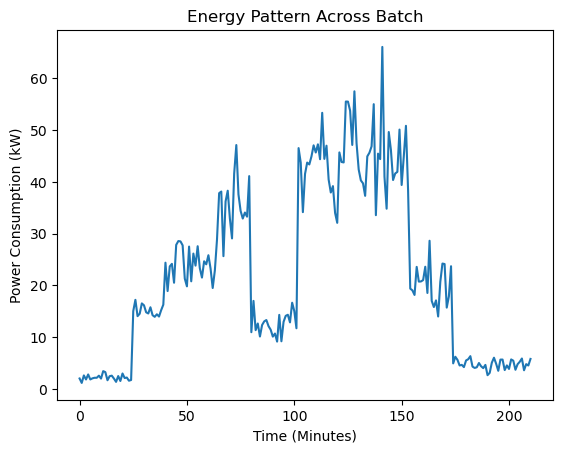

In [92]:
plt.figure()
plt.plot(df["Time_Minutes"], df["Power_Consumption_kW"])
plt.xlabel("Time (Minutes)")
plt.ylabel("Power Consumption (kW)")
plt.title("Energy Pattern Across Batch")
plt.show()

In [93]:
energy_mean = df["Power_Consumption_kW"].mean()
energy_std = df["Power_Consumption_kW"].std()

threshold = energy_mean + 2 * energy_std

df["Energy_Anomaly"] = df["Power_Consumption_kW"] > threshold

print("Number of Energy Anomalies:", df["Energy_Anomaly"].sum())

Number of Energy Anomalies: 5


In [94]:
def calculate_score(prediction):
    hardness, dissolution, uniformity, carbon = prediction
    
    score = (
        hardness * 0.3 +
        dissolution * 0.3 +
        uniformity * 0.2 -
        carbon * 0.2
    )
    
    return score

In [95]:
def optimize_parameters(model, sample_input):

    best_score = -999
    best_config = None

    for i in range(100):
        variation = sample_input + np.random.normal(0, 0.05, sample_input.shape)
        prediction = model.predict(variation)[0]
        score = calculate_score(prediction)

        if score > best_score:
            best_score = score
            best_config = variation

    return best_config, best_score


sample = X_test[0].reshape(1, -1)
best_config, best_score = optimize_parameters(model, sample)

print("Optimized Score:", best_score)

Optimized Score: 72.63685935029093


In [96]:
golden_signature = {
    "best_score": best_score,
    "best_config": best_config
}

print("Golden Signature Stored.")

Golden Signature Stored.


In [97]:
new_prediction = model.predict(sample)[0]
new_score = calculate_score(new_prediction)

if new_score > golden_signature["best_score"]:
    golden_signature["best_score"] = new_score
    golden_signature["best_config"] = sample
    print("Golden Signature Updated!")

In [98]:
carbon_limit = df["Carbon_Emission"].mean()

df["Carbon_Compliance"] = df["Carbon_Emission"] <= carbon_limit

print("Carbon Compliance Rate:",
      df["Carbon_Compliance"].mean() * 100, "%")

Carbon Compliance Rate: 56.872037914691944 %


In [99]:
# ---- USER INPUT SECTION ----

print("Enter Process Parameters")

time_input = float(input("Time (Minutes): "))
temp_input = float(input("Temperature (C): "))
pressure_input = float(input("Pressure (Bar): "))
humidity_input = float(input("Humidity (%): "))
speed_input = float(input("Motor Speed (RPM): "))
force_input = float(input("Compression Force (kN): "))
flow_input = float(input("Flow Rate (LPM): "))
power_input = float(input("Power Consumption (kW): "))
vibration_input = float(input("Vibration (mm/s): "))

user_data = np.array([[ 
    time_input,
    temp_input,
    pressure_input,
    humidity_input,
    speed_input,
    force_input,
    flow_input,
    power_input,
    vibration_input
]])

# Scale input
user_scaled = scaler.transform(user_data)

# Predict
prediction = model.predict(user_scaled)[0]

hardness, dissolution, uniformity, carbon = prediction

print("\n--- PREDICTION OUTPUT ---")
print("Predicted Hardness:", hardness)
print("Predicted Dissolution Rate:", dissolution)
print("Predicted Content Uniformity:", uniformity)
print("Predicted Carbon Emission:", carbon)

Enter Process Parameters


Time (Minutes):  12
Temperature (C):  23
Pressure (Bar):  34
Humidity (%):  45
Motor Speed (RPM):  56
Compression Force (kN):  67
Flow Rate (LPM):  78
Power Consumption (kW):  89
Vibration (mm/s):  90



--- PREDICTION OUTPUT ---
Predicted Hardness: 95.0
Predicted Dissolution Rate: 89.29999999999964
Predicted Content Uniformity: 98.70000000000041
Predicted Carbon Emission: 46.01332866204832


C:\Users\Kapse Swetha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [118]:
best_config, best_score = optimize_parameters(model, user_scaled)

optimized_prediction = model.predict(best_config)[0]

print("\n--- OPTIMIZED OUTPUT ---")
print("Optimized Hardness:", optimized_prediction[0])
print("Optimized Dissolution:", optimized_prediction[1])
print("Optimized Uniformity:", optimized_prediction[2])
print("Optimized Carbon:", optimized_prediction[3])
print("Optimization Score:", best_score)


--- OPTIMIZED OUTPUT ---
Optimized Hardness: 95.0
Optimized Dissolution: 89.29999999999964
Optimized Uniformity: 98.70000000000041
Optimized Carbon: 45.981851390570995
Optimization Score: 65.83362972188577
